# SetUp

In [16]:
import time
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import math
import torch.nn.functional as F
# import torch.optim as optim
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
# import random
import numpy as np
import git

In [2]:
from gromo.containers.growing_graph_network import GrowingGraphNetwork
from gromo.containers.growing_dag import GrowingDAG

In [3]:
# from ConfigSpace import Configuration, ConfigurationSpace
# from smac import HyperparameterOptimizationFacade, Scenario

In [4]:
import sys
if "../" not in sys.path:
    sys.path.append("../")

In [5]:
from wrappers.exp_graph_growing_net import ExpGrowingGraphNetwork
from tools.datasets import get_dataset
# from tools.utils import mini_batch_gradient_descent
from tools.logger import Logger

In [6]:
device = torch.device("mps" if torch.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Trainer

In [7]:
def div_remainder(n, interval):
    # finds divisor and remainder given some n/interval
    factor = math.floor(n / interval)
    remainder = int(n - (factor * interval))
    return factor, remainder

def show_time(seconds):
    # show amount of time as human readable
    if seconds < 60:
        return "{:.2f}s".format(seconds)
    elif seconds < (60 * 60):
        minutes, seconds = div_remainder(seconds, 60)
        return "{}m,{}s".format(minutes, seconds)
    else:
        hours, seconds = div_remainder(seconds, 60 * 60)
        minutes, seconds = div_remainder(seconds, 60)
        return "{}h,{}m,{}s".format(hours, minutes, seconds)

In [59]:
class Trainer:
    """
    ====================================================================================================================
    INIT ===============================================================================================================
    ====================================================================================================================
    The Trainer class will receive the following inputs
        * model: The model returned by your NAS class
        * train_loader: The train loader created by your DataProcessor
        * valid_loader: The valid loader created by your DataProcessor
        * metadata: A dictionary with information about this dataset, with the following keys:
            'num_classes' : The number of output classes in the classification problem
            'codename' : A unique string that represents this dataset
            'input_shape': A tuple describing [n_total_datapoints, channel, height, width] of the input data
            'time_remaining': The amount of compute time left for your submission
            plus anything else you added in the DataProcessor or NAS classes
    """
    def __init__(self, model, device, train_dataloader, valid_dataloader, metadata, logger, clock):
        self.model = model
        self.device = device
        self.train_dataloader = train_dataloader
        self.valid_dataloader = valid_dataloader
        self.metadata = metadata
        self.logger = logger
        self.clock = clock

        # define training parameters
        self.epochs = metadata['training_epochs']
        self.optimizer = metadata["optimizer"]
        self.scheduler = metadata["scheduler"]
        self.criterion = metadata["criterion"]

        print(f"  Training for {self.epochs} epochs")
        # self.optimizer = optim.SGD(model.parameters(), lr=.01, momentum=.9, weight_decay=3e-4)
        # self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
        # self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=self.weight_decay)
        # self.criterion = nn.CrossEntropyLoss()
        # self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.epochs)
        # self.scheduler = None

    """
    ====================================================================================================================
    TRAIN ==============================================================================================================
    ====================================================================================================================
    The train function will define how your model is trained on the train_dataloader.
    Output: Your *fully trained* model
    
    See the example submission for how this should look
    """
    def train(self):
        train_accuracies, val_accuracies = [], []
        best_acc = 0.0
        t_start = time.time()
        for epoch in range(self.epochs):
            self.model.train()
            labels, predictions = [], []
            epoch_loss = 0
            gradients = 0
            for data, target in self.train_dataloader:
                data, target = data.to(self.device), target.to(self.device)
                # print(f"{data.shape=} {target.shape=}")
                self.optimizer.zero_grad()
                output = self.model(data)

                # store labels and predictions to compute accuracy
                labels += target.cpu().tolist()
                predictions += torch.argmax(output, 1).detach().cpu().tolist()

                loss = self.criterion(output, target)
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()
                self.logger.log_metric("train batch loss", loss.item(), epoch)
                
                try:
                    avg_grad_norm = 0.0
                    for param in self.model.parameters():
                        avg_grad_norm += param.grad.norm().item()
                    avg_grad_norm /= len(list(self.model.parameters()))
                    self.logger.log_metric("gradient batch norm", avg_grad_norm, epoch)
                except AttributeError as err:
                    print(err)
                gradients += avg_grad_norm

            if self.scheduler:
                self.scheduler.step()
                    
            self.logger.log_metric("train loss", epoch_loss/len(self.train_dataloader), epoch)
            self.logger.log_metric("gradient norm", gradients/len(self.train_dataloader), epoch)
            train_acc = accuracy_score(labels, predictions)
            valid_acc = self.evaluate()
            self.logger.log_metric("train acc", train_acc, epoch)
            self.logger.log_metric("valid acc", valid_acc, epoch)

            train_accuracies.append(train_acc)
            val_accuracies.append(valid_acc)

            if valid_acc > best_acc:
                best_acc = valid_acc
                # save checkpoint
                torch.save(self.model.state_dict(), "best_allcnn_cifar10.pth")
            
            if (epoch + 1) % 5 == 0 or epoch == self.epochs or self.epochs <= 10:
                print("\tEpoch {:>3}/{:<3} | Train Acc: {:>6.2f}% | Valid Acc: {:>6.2f}% | T/Epoch: {:<7} |".format(
                    epoch + 1, self.epochs,
                    train_acc * 100, valid_acc * 100,
                    show_time((time.time() - t_start) / (epoch + 1))
                ))
        print("  Total runtime: {}".format(show_time(time.time() - t_start)))
        return self.model, train_accuracies, val_accuracies

    # print out the model's accuracy over the valid dataset
    # (this isn't necessary for a submission, but I like it for my training logs)
    def evaluate(self):
        self.model.eval()
        labels, predictions = [], []
        for data, target in self.valid_dataloader:
            data = data.to(self.device)
            output = self.model.forward(data)
            labels += target.cpu().tolist()
            predictions += torch.argmax(output, 1).detach().cpu().tolist()
        return accuracy_score(labels, predictions)


    """
    ====================================================================================================================
    PREDICT ============================================================================================================
    ====================================================================================================================
    The prediction function will define how the test dataloader will be passed through your model. It will receive:
        * test_dataloader created by your DataProcessor
    
    And expects as output:
        A list/array of predicted class labels of length=n_test_datapoints, i.e, something like [0, 0, 1, 5, ..., 9] 
    
    See the example submission for how this should look.
    """

    def predict(self, test_loader):
        self.model.eval()
        predictions = []
        for data, labels in test_loader:
            data = data.to(self.device)
            output = self.model.forward(data)
            predictions += torch.argmax(output, 1).detach().cpu().tolist()
        return predictions

# Data

In [17]:
trainset, valset, testset = get_dataset("cifar10", "../data", split_train_val=0.3)
print(f"{len(trainset)}")
# in_features = 28 * 28 * 3
out_features = len(np.unique(trainset.dataset.targets))

35000


In [18]:
train_loader = torch.utils.data.DataLoader(trainset, 64)
val_loader = torch.utils.data.DataLoader(valset, 64)
test_loader = torch.utils.data.DataLoader(testset, 128)

# Logger

In [11]:
repo = git.Repo(search_parent_directories=True)
git_commit = repo.head.object.hexsha
try:
    gpu_index = torch.cuda.current_device()
except:
    gpu_index = None
tags = {
    "git.commit": git_commit,
    # "slurm.job_id": args.job_id,
    # "slurm.node_name": args.node_name,
    "gpu_index": gpu_index,
}

In [12]:
logger = Logger("Vanilla")
logger.setup_tracking(file_path="../mlruns")

# ALL-CNN-C

In [10]:
# # Fix random seeds (for reproducibility)
# def seed_everything(seed=1234):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# seed_everything(0)

In [11]:
# Define the ALL-CNN-C model
class AllCNN_C(nn.Module):
    def __init__(self, num_classes=10):
        super(AllCNN_C, self).__init__()
        # According to Springenberg et al. (“Striving for Simplicity”) architecture
        self.dropout0 = nn.Dropout(0.2)
        self.conv1 = nn.Conv2d(3, 96, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(96, 96, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(96, 96, kernel_size=3, stride=2, padding=1)  # downsample 32 → 16
        self.dropout1 = nn.Dropout(0.5)

        self.conv4 = nn.Conv2d(96, 192, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(192, 192, kernel_size=3, stride=2, padding=1)  # downsample 16 → 8
        self.dropout2 = nn.Dropout(0.5)

        self.conv7 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)
        self.conv8 = nn.Conv2d(192, 192, kernel_size=1, stride=1, padding=0)
        self.conv9 = nn.Conv2d(192, num_classes, kernel_size=1, stride=1, padding=0)

        # No fully connected layers; global average pooling will reduce to (num_classes,)
        # Note: The spatial map before GAP should be 8×8, so average over that.

    def forward(self, x):
        x = self.dropout0(x)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.dropout1(x)

        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.dropout2(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = F.relu(self.conv9(x))

        # Global average pool (spatial → 1×1)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)  # flatten to (batch, num_classes)
        return x

# # Training and evaluation functions
# def train_one_epoch(model, device, train_loader, optimizer, criterion, epoch, verbose=True):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
#     for batch_idx, (inputs, targets) in enumerate(train_loader):
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item() * inputs.size(0)
#         _, predicted = outputs.max(1)
#         total += targets.size(0)
#         correct += predicted.eq(targets).sum().item()

#     epoch_loss = running_loss / total
#     epoch_acc = correct / total
#     if verbose:
#         print(f"Train Epoch {epoch}: Loss {epoch_loss:.4f}, Accuracy {100 * epoch_acc:.2f}%")
#     return epoch_loss, epoch_acc

# def eval_model(model, device, test_loader, criterion, verbose=True):
#     model.eval()
#     test_loss = 0.0
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for inputs, targets in test_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             test_loss += loss.item() * inputs.size(0)
#             _, predicted = outputs.max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()

#     avg_loss = test_loss / total
#     acc = correct / total
#     if verbose:
#         print(f"Test: Loss {avg_loss:.4f}, Accuracy {100 * acc:.2f}%")
#     return avg_loss, acc

In [ ]:
batch_size = 64
num_epochs = 350
init_lr = 0.01
weight_decay = 1e-3
momentum = 0.9

model = AllCNN_C(num_classes=10).to(device)

cuda


In [15]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=init_lr, momentum=momentum, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[200, 250, 300])

metadata = {
    "training_epochs": num_epochs,
    "optimizer": optimizer,
    "scheduler": scheduler,
    "criterion": criterion,
}

trainer = Trainer(model, device=device,
        train_dataloader=train_loader,
        valid_dataloader=val_loader,
        metadata=metadata,
        logger=logger,
        clock=None,
)

with logger(tags=tags):
    for param, value in metadata.items():
        logger.log_parameter(param, value)

    trained_model, train_acc, val_acc = trainer.train()

predictions = trainer.predict(test_loader)

print("Predictions on test data:", predictions)

2025/10/15 12:45:10 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  Training for 350 epochs
	Epoch   5/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.35s   |
	Epoch  10/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.33s   |
	Epoch  15/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  20/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  25/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  30/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  35/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  40/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  45/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  50/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  55/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  60/350 | Train Acc:  10.34% | Valid Acc:   9.92% | T/Epoch: 7.31s   |
	Epoch  65/350 | Train Acc:  10.34% | 

2025/10/15 12:54:19 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2025/10/15 12:54:20 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


KeyboardInterrupt: 

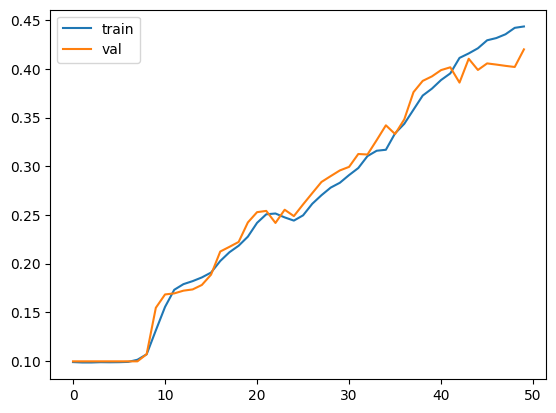

In [ ]:
plt.figure()
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.legend()
plt.show()

# ResNet

In [19]:
from torchvision.models import resnet50, ResNet50_Weights

In [60]:
resnet = resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc = nn.Linear(in_features=2048, out_features=out_features, bias=True).to(device)

In [61]:

# resnet = resnet50(num_classes=10).to(device)

num_epochs = 350
lrate=1e-3
weight_decay = 1e-3

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet.parameters(), lr=lrate, weight_decay=weight_decay)

metadata = {
    "training_epochs": num_epochs,
    "optimizer": optimizer,
    "scheduler": None,
    "criterion": criterion,
}

trainer = Trainer(resnet, device=device,
        train_dataloader=train_loader,
        valid_dataloader=val_loader,
        metadata=metadata,
        logger=logger,
        clock=None,
)

with logger(tags=tags):
    for param, value in metadata.items():
        logger.log_parameter(param, value)

    trained_model, train_acc, val_acc = trainer.train()

predictions = trainer.predict(test_loader)

print("Predictions on test data:", predictions)

2025/10/22 12:21:55 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  Training for 350 epochs
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneType' object has no attribute 'norm'
'NoneTyp

2025/10/22 12:29:18 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2025/10/22 12:29:18 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


'NoneType' object has no attribute 'norm'


KeyboardInterrupt: 

# Monster DAG

GrowingDAG with 11 nodes and 15 edges


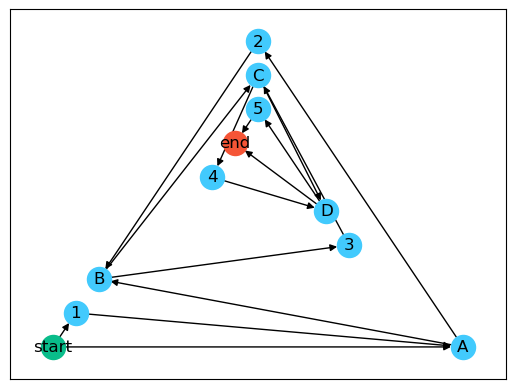

In [ ]:
root, end = "start", "end"
edges = [(root, "A"), ("A", "B"), ("B", "C"), ("C", "D"), ("D", end), (root, "1"), ("1", "A"), ("A", "2"), ("2", "B"), ("B", "3"), ("3", "C"), ("C", "4"), ("4", "D"), ("D", "5"), ("5", end)]
node_attributes = {
    root: {
        "type": "linear",  # shows what follows
        "size": in_features,
        "activation": "flatten",
    },
    end: {
        "type": "linear",
        "size": out_features,
    },
    "A": {"type": "linear", "size": 150, "activation": "selu"},
    "B": {"type": "linear", "size": 150, "activation": "selu"},
    "C": {"type": "linear", "size": 150, "activation": "selu"},
    "D": {"type": "linear", "size": 150, "activation": "selu"},
    # "E": {"type": "linear", "size": 150, "activation": "selu"},
    # "F": {"type": "linear", "size": 150, "activation": "selu"},
    "1": {"type": "linear", "size": 50, "activation": "selu"},
    "2": {"type": "linear", "size": 50, "activation": "selu"},
    "3": {"type": "linear", "size": 50, "activation": "selu"},
    "4": {"type": "linear", "size": 50, "activation": "selu"},
    "5": {"type": "linear", "size": 50, "activation": "selu"},
}
edge_attributes = {
    "type": "linear",
    "use_bias": True,
}

DAG_parameters = {}
DAG_parameters["edges"] = edges
DAG_parameters["node_attributes"] = node_attributes
DAG_parameters["edge_attributes"] = edge_attributes

model = ExpGrowingGraphNetwork(
    in_features=in_features,
    out_features=out_features,
    neurons=20,
    use_batch_norm=False,
    loss_fn=torch.nn.CrossEntropyLoss(),
    with_logger=False,
)

dag = GrowingDAG(in_features=in_features, out_features=out_features, neurons=20, use_bias=True, use_batch_norm=False, DAG_parameters=DAG_parameters)
model.dag = dag
print(model.dag)
model.draw()

In [ ]:
metadata = {
    # "training_epochs": 1_000,
    "training_epochs": 400,
    "weight_decay": 0,
}

trainer = Trainer(model, device=model.device,
        train_dataloader=train_loader,
        valid_dataloader=val_loader,
        metadata=metadata,
        clock=None,
)

trained_model, train_acc, val_acc = trainer.train()
predictions = trainer.predict(test_loader)

  Training for 400 epochs with weight decay 0
	Epoch   5/400 | Train Acc:  69.69% | Valid Acc:  61.35% | T/Epoch: 3.00s   |
	Epoch  10/400 | Train Acc:  85.43% | Valid Acc:  70.69% | T/Epoch: 3.08s   |
	Epoch  15/400 | Train Acc:  90.63% | Valid Acc:  74.12% | T/Epoch: 3.11s   |
	Epoch  20/400 | Train Acc:  93.36% | Valid Acc:  74.09% | T/Epoch: 3.13s   |
	Epoch  25/400 | Train Acc:  94.46% | Valid Acc:  75.43% | T/Epoch: 3.14s   |
	Epoch  30/400 | Train Acc:  95.49% | Valid Acc:  75.29% | T/Epoch: 3.17s   |
	Epoch  35/400 | Train Acc:  95.98% | Valid Acc:  76.54% | T/Epoch: 3.14s   |
	Epoch  40/400 | Train Acc:  96.20% | Valid Acc:  75.87% | T/Epoch: 3.18s   |
	Epoch  45/400 | Train Acc:  96.68% | Valid Acc:  76.52% | T/Epoch: 3.23s   |
	Epoch  50/400 | Train Acc:  96.65% | Valid Acc:  77.75% | T/Epoch: 3.23s   |
	Epoch  55/400 | Train Acc:  97.56% | Valid Acc:  76.96% | T/Epoch: 3.21s   |
	Epoch  60/400 | Train Acc:  97.18% | Valid Acc:  77.34% | T/Epoch: 3.19s   |
	Epoch  65/400 | T

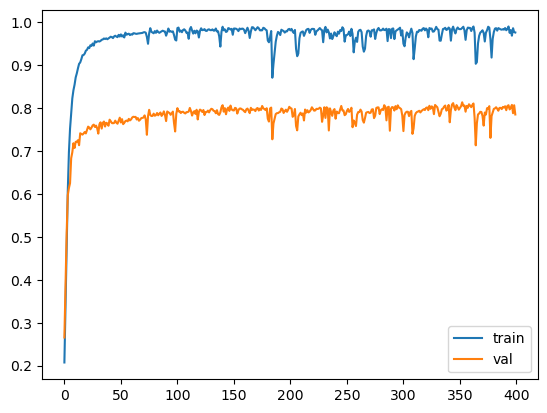

In [ ]:
plt.figure()
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.legend()
plt.show()

  Training for 100 epochs with weight decay 0
	Epoch   5/100 | Train Acc:  98.55% | Valid Acc:  80.63% | T/Epoch: 3.83s   |
	Epoch  10/100 | Train Acc:  97.83% | Valid Acc:  79.83% | T/Epoch: 3.80s   |
	Epoch  15/100 | Train Acc:  95.92% | Valid Acc:  76.95% | T/Epoch: 3.86s   |
	Epoch  20/100 | Train Acc:  97.72% | Valid Acc:  80.19% | T/Epoch: 3.88s   |
	Epoch  25/100 | Train Acc:  98.52% | Valid Acc:  79.46% | T/Epoch: 3.90s   |
	Epoch  30/100 | Train Acc:  95.06% | Valid Acc:  76.63% | T/Epoch: 3.89s   |
	Epoch  35/100 | Train Acc:  96.52% | Valid Acc:  79.24% | T/Epoch: 3.89s   |
	Epoch  40/100 | Train Acc:  92.52% | Valid Acc:  74.46% | T/Epoch: 3.90s   |
	Epoch  45/100 | Train Acc:  93.51% | Valid Acc:  74.91% | T/Epoch: 3.92s   |
	Epoch  50/100 | Train Acc:  97.95% | Valid Acc:  79.65% | T/Epoch: 3.93s   |
	Epoch  55/100 | Train Acc:  93.96% | Valid Acc:  76.95% | T/Epoch: 3.92s   |
	Epoch  60/100 | Train Acc:  97.08% | Valid Acc:  78.78% | T/Epoch: 3.91s   |
	Epoch  65/100 | T

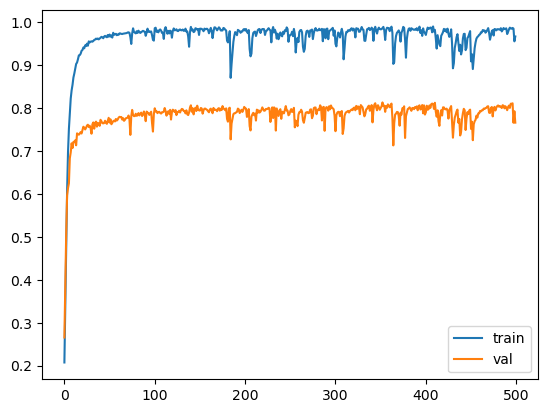

In [ ]:
metadata = {
    "training_epochs": 100,
    "weight_decay": 0,
}

trainer = Trainer(trained_model, device=model.device,
        train_dataloader=train_loader,
        valid_dataloader=val_loader,
        metadata=metadata,
        clock=None,
)

trained_model2, _train_acc, _val_acc = trainer.train()
train_acc.extend(_train_acc)
val_acc.extend(_val_acc)

plt.figure()
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.legend()
plt.show()

# End